# Лабораторна робота: Класифікація даних (Modeling & Evaluation)

**Мета:** Створити та дослідити набори даних для задачі класифікації, провести попередню обробку та оцінити якість моделей згідно з теоретичними метриками (Precision, Recall, F1).

**Завдання:**
1.  Генерація даних через DatasetGenerator.
2.  Робота з реальним датасетом (Kaggle).
3.  (Додатково) Генерація даних засобами NumPy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

sns.set(style="whitegrid")
print("Бібліотеки завантажено!")

Бібліотеки завантажено!


## 1. Генерація даних (sklearn.make_classification)
Створимо синтетичний набір даних. Згідно з теорією, штучні дані часто мають чіткі ознаки, що полегшує класифікацію.

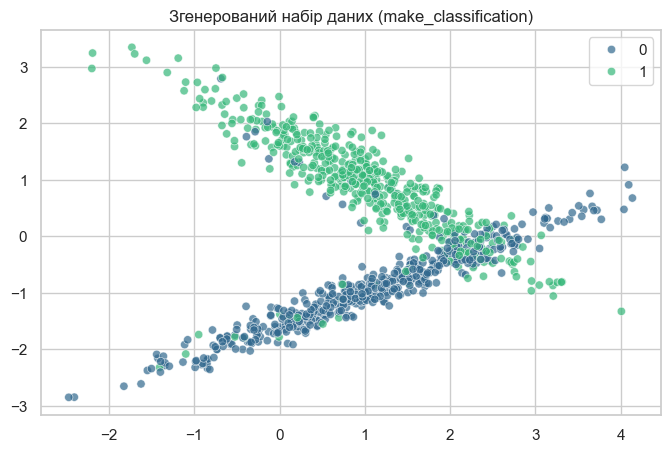

--- Результати на згенерованих даних ---
Accuracy:  0.8950
Precision: 0.9307
Recall:    0.8704
F1-Score:  0.8995


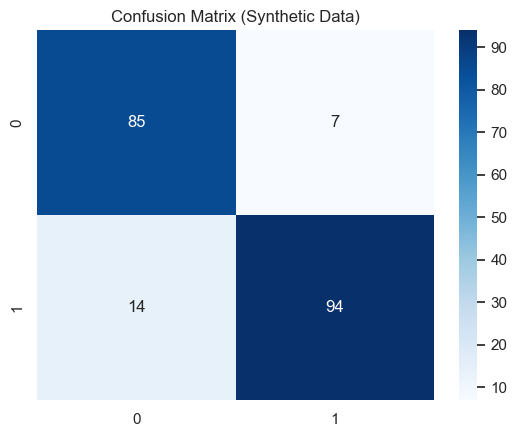

In [2]:
X, y = make_classification(
    n_samples=1000, 
    n_features=2,      
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    flip_y=0.1,   
    random_state=42
)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.title("Згенерований набір даних (make_classification)")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("--- Результати на згенерованих даних ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Synthetic Data)")
plt.show()

## 2. Робота з реальним датасетом (Kaggle)
Реальні дані часто незбалансовані та містять пропуски. 

**Етапи обробки:**
1.  Обробка пропусків (Imputation).
2.  Кодування категорій (Encoding).
3.  Масштабування (Scaling).

In [3]:
filename = 'mushrooms.csv'

try:
    df = pd.read_csv(filename)
    
    if df.shape[1] < 2:
        print("Схоже, роздільник файлу - ';'. Перечитуємо файл...")
        df = pd.read_csv(filename, sep=';')

    print("Дані завантажено. Перші рядки:")
    display(df.head())
    print("\nТипи даних до обробки:")
    print(df.dtypes)
    
    target_col = 'target' 
    if target_col not in df.columns:
        target_col = df.columns[-1]
    
    print(f"\nЦільова колонка (y): {target_col}")

    X_real = df.drop(columns=[target_col])
    y_real = df[target_col]

    for col in X_real.columns:
        # errors='coerce' перетворить нечислові символи на NaN (пропуски)
        X_real[col] = pd.to_numeric(X_real[col], errors='ignore')

    num_cols = X_real.select_dtypes(include=['number']).columns
    cat_cols = X_real.select_dtypes(exclude=['number']).columns

    print(f"Знайдено числових колонок: {len(num_cols)}")
    print(f"Знайдено категоріальних колонок: {len(cat_cols)}")

    if len(num_cols) > 0:
        imputer = SimpleImputer(strategy='mean')
        X_real[num_cols] = imputer.fit_transform(X_real[num_cols])
    else:
        print("УВАГА: Числових колонок для імпутації не знайдено!")

    if len(cat_cols) > 0:
        X_real = pd.get_dummies(X_real, columns=cat_cols, drop_first=True)

    if X_real.shape[1] == 0:
        raise ValueError("Помилка: Не залишилось даних для навчання (всі колонки видалено або пусті).")

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_real, y_real, test_size=0.3, random_state=42)
    
    scaler_r = StandardScaler()
    X_train_r = scaler_r.fit_transform(X_train_r)
    X_test_r = scaler_r.transform(X_test_r)

    model_real = LogisticRegression(max_iter=1000)
    model_real.fit(X_train_r, y_train_r)
    y_pred_r = model_real.predict(X_test_r)

    print("\n--- Результати на Kaggle Dataset ---")
    print(classification_report(y_test_r, y_pred_r))

except FileNotFoundError:
    print(f"Файл '{filename}' не знайдено. Перевірте, чи файл лежить поруч з .ipynb")
except Exception as e:
    print(f"Виникла помилка: {e}")

Дані завантажено. Перші рядки:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



Типи даних до обробки:
class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

Цільова колонка (y): habitat
Знайдено числових колонок: 0
Знайдено категоріальних колонок: 22
УВАГА: Числових колонок для імпутації не знайдено!


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3912\1877642787.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_real[col] = pd.to_numeric(X_real[col], errors='ignore')



--- Результати на Kaggle Dataset ---
              precision    recall  f1-score   support

           d       0.79      0.74      0.76       933
           g       0.66      0.70      0.68       660
           l       0.46      0.57      0.51       230
           m       0.39      0.35      0.37        91
           p       0.29      0.26      0.28       353
           u       0.58      0.55      0.56       124
           w       1.00      1.00      1.00        47

    accuracy                           0.63      2438
   macro avg       0.59      0.60      0.59      2438
weighted avg       0.63      0.63      0.63      2438



## 3. Генерація даних засобами NumPy (Опціонально)
Створимо два кластери точок, використовуючи нормальний розподіл (`np.random.normal`), без використання бібліотеки sklearn для генерації. Це дозволяє краще зрозуміти природу даних.

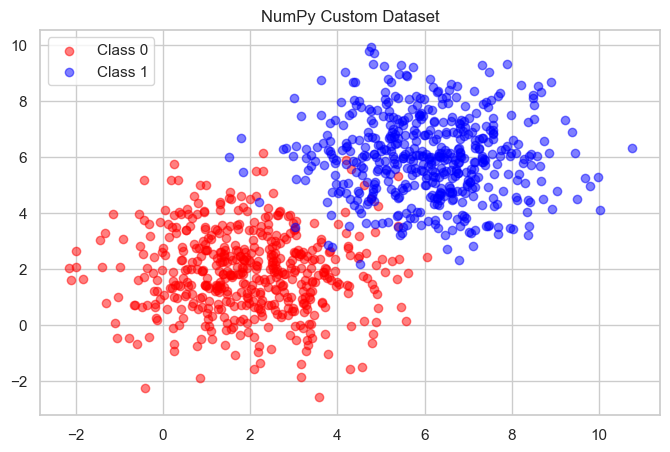

--- Результати на NumPy Custom Dataset ---
F1-Score: 0.9706


In [4]:
np.random.seed(0)
n_samples = 500

class_0_x = np.random.normal(2, 1.5, n_samples)
class_0_y = np.random.normal(2, 1.5, n_samples)
labels_0 = np.zeros(n_samples)

class_1_x = np.random.normal(6, 1.5, n_samples)
class_1_y = np.random.normal(6, 1.5, n_samples)
labels_1 = np.ones(n_samples)

X_custom = np.vstack((
    np.column_stack((class_0_x, class_0_y)),
    np.column_stack((class_1_x, class_1_y))
))
y_custom = np.concatenate((labels_0, labels_1))

indices = np.arange(X_custom.shape[0])
np.random.shuffle(indices)
X_custom = X_custom[indices]
y_custom = y_custom[indices]

plt.figure(figsize=(8, 5))
plt.scatter(X_custom[y_custom==0][:,0], X_custom[y_custom==0][:,1], color='red', label='Class 0', alpha=0.5)
plt.scatter(X_custom[y_custom==1][:,0], X_custom[y_custom==1][:,1], color='blue', label='Class 1', alpha=0.5)
plt.title("NumPy Custom Dataset")
plt.legend()
plt.show()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_custom, y_custom, test_size=0.2)
model_c = LogisticRegression()
model_c.fit(X_train_c, y_train_c)
y_pred_c = model_c.predict(X_test_c)

print("--- Результати на NumPy Custom Dataset ---")
print(f"F1-Score: {f1_score(y_test_c, y_pred_c):.4f}")

# Висновки
Аналізуючи метрики Precision, Recall та F1 на різних наборах даних, можна зазначити, що Синтетичні дані зазвичай показують найвищу точність, оскільки класи добре розділені та не мають шумів реального світу. Реальні дані результати можуть бути нижчими через дисбаланс класів або корельовані ознаки. Якщо F1-score низький, варто спробувати балансування класів або іншу модель. Обробка даних - критично важливими етапами були заповнення пропусків та масштабування, без яких модель могла б видати помилку або невірні результати.